# Simple DSM Quality Analysis

A streamlined notebook for analyzing DSM (Digital Surface Model) prediction quality.

**What this notebook does:**
1. Parse test log files to extract metrics (RMSE, MAE, Delta1, etc.)
2. Divide tiles into performance quartiles 
3. Create basic visualizations of best/worst performing tiles
4. Generate summary statistics

**Configuration:** Just change the `DATASET_NAME` variable below to analyze different datasets.

In [35]:
# Configuration - Change these variables for your dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset to analyze
DATASET_NAME = 'DFC2019_crp512_bin'  # Change this: 'DFC2023S', 'DFC2019_crp512_bin', 'Huawei_Contest'

# Paths
BASE_DATASETS_PATH = '/home/asfand/Ahmad/datasets'
BASE_OUTPUT_PATH = '/home/asfand/Ahmad/DSMNet/output'

# SAR datasets need special path handling
SAR_DATASETS = ['DFC2023']
has_sar = any(DATASET_NAME.startswith(d) for d in SAR_DATASETS)
sar_suffix = '/-sar' if has_sar else ''

# Construct paths
DATASET_PATH = os.path.join(BASE_DATASETS_PATH, DATASET_NAME)
OUTPUT_PATH = os.path.join(BASE_OUTPUT_PATH, DATASET_NAME + sar_suffix)
LOG_FILE = os.path.join(OUTPUT_PATH, '_logs', f'{DATASET_NAME}_dae_test_output.log')

print(f"Analyzing: {DATASET_NAME}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Log file: {LOG_FILE}")
print(f"Paths exist: Dataset={os.path.exists(DATASET_PATH)}, Output={os.path.exists(OUTPUT_PATH)}")

Analyzing: DFC2019_crp512_bin
Dataset path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin
Output path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin
Log file: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/_logs/DFC2019_crp512_bin_dae_test_output.log
Paths exist: Dataset=True, Output=True


In [36]:
# Simple log parsing function
import re

def parse_log_simple(log_file_path):
    """Parse test log file and extract metrics per tile."""
    if not os.path.exists(log_file_path):
        print(f"Log file not found: {log_file_path}")
        # Try to find alternative log files before creating mock data
        log_dir = os.path.dirname(log_file_path)
        if os.path.exists(log_dir):
            log_files = [f for f in os.listdir(log_dir) if f.endswith('.log')]
            if log_files:
                alternative_log = os.path.join(log_dir, log_files[0])
                print(f"Found alternative log file: {alternative_log}")
                return parse_log_simple(alternative_log)
        
        print("No log files found - creating mock data for demonstration")
        return create_mock_data()
    
    tiles_data = []
    current_tile = None
    current_metrics = {}
    
    # Patterns to extract data
    tile_pattern = r"Current test tile #\d+/\d+: (.+)"
    metric_patterns = {
        'rmse': r"Tile RMSE\s*:\s*([\d.]+)",
        'mae': r"Tile MAE\s*:\s*([\d.]+)", 
        'delta1': r"Tile Delta1:\s*([\d.]+)",
        'delta2': r"Tile Delta2:\s*([\d.]+)",
        'delta3': r"Tile Delta3:\s*([\d.]+)",
        'rmse_building': r"Tile RMSE Building:\s*([\d.]+)",
        'rmse_matched': r"Tile RMSE Matched\s*:\s*([\d.]+)",
        'low_rise_rmse': r"Tile Low-rise RMSE:\s*([\d.]+)",
        'mid_rise_rmse': r"Tile Mid-rise RMSE:\s*([\d.]+)",
        'high_rise_rmse': r"Tile High-rise RMSE:\s*([\d.]+)",
        'processing_time': r"Tile time\s*:\s*([\d.]+)"
    }
    
    print(f"Parsing log file: {log_file_path}")
    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                line = line.strip()
                
                # Check for tile name
                tile_match = re.search(tile_pattern, line)
                if tile_match:
                    # Save previous tile if exists
                    if current_tile and current_metrics:
                        tiles_data.append({'tile_name': current_tile, **current_metrics})
                    
                    current_tile = tile_match.group(1)
                    current_metrics = {}
                    continue
                
                # Check for metrics
                for metric_name, pattern in metric_patterns.items():
                    match = re.search(pattern, line)
                    if match:
                        current_metrics[metric_name] = float(match.group(1))
            
            # Add last tile
            if current_tile and current_metrics:
                tiles_data.append({'tile_name': current_tile, **current_metrics})
                
    except Exception as e:
        print(f"Error parsing log: {e}")
        return create_mock_data()
    
    if not tiles_data:
        print("No tile data found in log file, creating mock data")
        return create_mock_data()
        
    print(f"Successfully parsed {len(tiles_data)} tiles from log file")
    return pd.DataFrame(tiles_data)

def create_mock_data(n_tiles=50):
    """Create mock data for demonstration when no real data is available."""
    print(f"Creating mock data with {n_tiles} tiles for demonstration...")
    np.random.seed(42)
    tiles = [f"tile_{i:03d}" for i in range(1, n_tiles+1)]
    
    data = {
        'tile_name': tiles,
        'rmse': np.abs(np.random.normal(5.0, 2.0, n_tiles)),
        'mae': np.abs(np.random.normal(3.5, 1.5, n_tiles)),
        'delta1': np.random.beta(2, 1, n_tiles),
        'rmse_building': np.abs(np.random.normal(6.0, 2.5, n_tiles)),
        'rmse_matched': np.abs(np.random.normal(4.5, 1.8, n_tiles))
    }
    
    return pd.DataFrame(data)

print("Enhanced parsing functions defined")

Enhanced parsing functions defined


In [37]:
# Load and analyze the data
print("Loading metrics data...")
metrics_df = parse_log_simple(LOG_FILE)

print(f"\nDataset: {DATASET_NAME}")
print(f"Total tiles: {len(metrics_df)}")
print(f"Available metrics: {list(metrics_df.columns)}")

# Show basic statistics
if 'rmse' in metrics_df.columns:
    rmse_stats = metrics_df['rmse'].describe()
    print(f"\nRMSE Statistics:")
    print(f"  Mean: {rmse_stats['mean']:.3f}")
    print(f"  Median: {rmse_stats['50%']:.3f}")
    print(f"  Min: {rmse_stats['min']:.3f}")
    print(f"  Max: {rmse_stats['max']:.3f}")
    print(f"  Std: {rmse_stats['std']:.3f}")

# Show first few rows
print(f"\nFirst 5 tiles:")
display(metrics_df.head())

Loading metrics data...
Parsing log file: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/_logs/DFC2019_crp512_bin_dae_test_output.log
Successfully parsed 4000 tiles from log file

Dataset: DFC2019_crp512_bin
Total tiles: 4000
Available metrics: ['tile_name', 'mae', 'rmse', 'delta1', 'delta2', 'delta3', 'rmse_building', 'rmse_matched', 'low_rise_rmse', 'mid_rise_rmse', 'processing_time', 'high_rise_rmse']

RMSE Statistics:
  Mean: 3.420
  Median: 1.733
  Min: 0.000
  Max: 61.535
  Std: 5.533

First 5 tiles:


,tile_name,mae,rmse,delta1,delta2,delta3,rmse_building,rmse_matched,low_rise_rmse,mid_rise_rmse,processing_time,high_rise_rmse
0,JAX_004_007_crop06,0.5621,1.3993,0.7245,0.7271,0.7450,3.1939,2.0759,3.1843,15.7842,34.613030,NaN
1,JAX_004_009_crop07,0.4157,1.3208,0.8261,0.8277,0.8381,3.6617,1.8808,3.7182,15.9432,0.179322,NaN
2,JAX_004_010_crop06,0.5186,1.4662,0.7914,0.7937,0.8052,3.5918,1.9600,3.6243,15.6777,0.171147,NaN
3,JAX_004_010_crop07,0.6169,1.6079,0.7546,0.7573,0.7691,3.6491,2.1852,3.6791,15.6701,0.165174,NaN
4,JAX_004_010_crop08,0.4203,1.3962,0.8323,0.8341,0.8431,3.9529,2.0223,3.8788,15.8872,0.156464,NaN


In [38]:
# Clear any previous mock data and verify data source
# Clean up any residual mock data variables
for var in ['mock_rgb', 'mock_gt', 'mock_pred', 'mock_diff']:
    if var in globals():
        del globals()[var]

# Verify we're working with the intended dataset
print(f"\n📊 DATA SOURCE VERIFICATION:")
print(f"  Target dataset: {DATASET_NAME}")
print(f"  Log file path: {LOG_FILE}")
print(f"  Log file exists: {os.path.exists(LOG_FILE)}")

if os.path.exists(LOG_FILE):
    print(f"  ✅ Using REAL log data from {DATASET_NAME}")
    # Show first few lines of log file for verification
    with open(LOG_FILE, 'r') as f:
        lines = f.readlines()[:10]
        print(f"  Sample log content (first 10 lines):")
        for i, line in enumerate(lines):
            print(f"    {i+1}: {line.strip()[:80]}...")
else:
    print(f"  ⚠️  Log file not found - will use mock data")
    
    # Check if there are any alternative log files
    log_dir = os.path.dirname(LOG_FILE)
    if os.path.exists(log_dir):
        log_files = [f for f in os.listdir(log_dir) if f.endswith('.log')]
        if log_files:
            print(f"  Available log files in {log_dir}:")
            for lf in log_files:
                print(f"    - {lf}")

print(f"\n🗂️  DATASET STRUCTURE CHECK:")
if os.path.exists(DATASET_PATH):
    test_path = os.path.join(DATASET_PATH, 'test')
    if os.path.exists(test_path):
        subdirs = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]
        print(f"  Test subdirectories: {subdirs}")
        
        # Count files in key directories
        for subdir in ['rgb', 'dsm']:
            subdir_path = os.path.join(test_path, subdir)
            if os.path.exists(subdir_path):
                file_count = len([f for f in os.listdir(subdir_path) if f.endswith('.tif')])
                print(f"  {subdir}/ contains {file_count} .tif files")
    else:
        print(f"  ❌ No test directory found in {DATASET_PATH}")
else:
    print(f"  ❌ Dataset path does not exist: {DATASET_PATH}")

print(f"\n📁 OUTPUT STRUCTURE CHECK:")
if os.path.exists(OUTPUT_PATH):
    subdirs = [d for d in os.listdir(OUTPUT_PATH) if os.path.isdir(os.path.join(OUTPUT_PATH, d))]
    print(f"  Output subdirectories: {subdirs}")
    
    # Check prediction directories
    pred_dirs = [d for d in subdirs if 'dsm' in d.lower()]
    for pred_dir in pred_dirs:
        pred_path = os.path.join(OUTPUT_PATH, pred_dir)
        file_count = len([f for f in os.listdir(pred_path) if f.endswith('.tif')])
        print(f"  {pred_dir}/ contains {file_count} .tif files")
else:
    print(f"  ❌ Output path does not exist: {OUTPUT_PATH}")

print("-" * 60)


📊 DATA SOURCE VERIFICATION:
  Target dataset: DFC2019_crp512_bin
  Log file path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/_logs/DFC2019_crp512_bin_dae_test_output.log
  Log file exists: True
  ✅ Using REAL log data from DFC2019_crp512_bin
  Sample log content (first 10 lines):
    1: 2025-07-28 04:40:06,864 - INFO -...
    2: Number of test samples: 4000...
    3: ...
    4: 2025-07-28 04:40:11,883 - INFO -...
    5: Current test tile #1/4000: JAX_004_007_crop06...
    6: 2025-07-28 04:40:47,175 - INFO - Applied binary segmentation masks:...
    7: 2025-07-28 04:40:47,175 - INFO -   - Prediction mask to predicted DSM...
    8: 2025-07-28 04:40:47,175 - INFO -   - Ground truth mask to ground truth DSM...
    9: 2025-07-28 04:40:47,176 - INFO - Masked out 76.74% of pixels in predicted DSM...
    10: 2025-07-28 04:40:47,176 - INFO - Masked out 82.80% of pixels in ground truth DSM...

🗂️  DATASET STRUCTURE CHECK:
  Test subdirectories: ['dsm', 'sem', 'rgb']
  rgb/ contains 400

In [39]:
# Divide into quartiles and find best/worst performers
metric = 'rmse'  # Primary metric for analysis

if metric in metrics_df.columns:
    # Sort by metric (ascending for RMSE - lower is better)
    sorted_df = metrics_df.sort_values(metric)
    n_tiles = len(sorted_df)
    
    # Divide into quartiles
    q1_end = n_tiles // 4
    q2_end = n_tiles // 2
    q3_end = 3 * n_tiles // 4
    
    quartiles = {
        'Q1 (Best)': sorted_df.iloc[:q1_end],
        'Q2': sorted_df.iloc[q1_end:q2_end], 
        'Q3': sorted_df.iloc[q2_end:q3_end],
        'Q4 (Worst)': sorted_df.iloc[q3_end:]
    }
    
    print(f"Quartile Analysis (based on {metric.upper()}):")
    print("-" * 50)
    
    for q_name, q_data in quartiles.items():
        q_mean = q_data[metric].mean()
        q_min = q_data[metric].min()
        q_max = q_data[metric].max()
        print(f"{q_name}: {len(q_data)} tiles, {metric}=[{q_min:.3f} to {q_max:.3f}], mean={q_mean:.3f}")
    
    # Sample a few tiles from each quartile for detailed look
    n_samples = 3
    sampled_tiles = {}
    
    for q_name, q_data in quartiles.items():
        if len(q_data) >= n_samples:
            samples = q_data.sample(n=n_samples, random_state=42)
        else:
            samples = q_data
        sampled_tiles[q_name] = samples
        
        print(f"\n{q_name} samples:")
        for _, row in samples.iterrows():
            print(f"  {row['tile_name']}: {metric}={row[metric]:.3f}")
            
else:
    print(f"Metric '{metric}' not found in data")

Quartile Analysis (based on RMSE):
--------------------------------------------------
Q1 (Best): 1000 tiles, rmse=[0.000 to 0.852], mean=0.340
Q2: 1000 tiles, rmse=[0.852 to 1.731], mean=1.328
Q3: 1000 tiles, rmse=[1.736 to 3.391], mean=2.474
Q4 (Worst): 1000 tiles, rmse=[3.393 to 61.535], mean=9.538

Q1 (Best) samples:
  OMA_258_030_crop05: rmse=0.354
  JAX_175_012_crop03: rmse=0.557
  OMA_258_032_crop01: rmse=0.559

Q2 samples:
  OMA_389_015_crop04: rmse=1.362
  OMA_357_001_crop01: rmse=1.540
  OMA_042_023_crop06: rmse=1.541

Q3 samples:
  JAX_280_025_crop07: rmse=2.510
  JAX_260_012_crop01: rmse=2.863
  JAX_467_019_crop08: rmse=2.868

Q4 (Worst) samples:
  JAX_260_026_crop05: rmse=6.134
  JAX_175_023_crop08: rmse=11.995
  OMA_288_011_crop02: rmse=12.089


/tmp/ipykernel_3214058/3798246851.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(quartile_values, labels=quartile_labels)


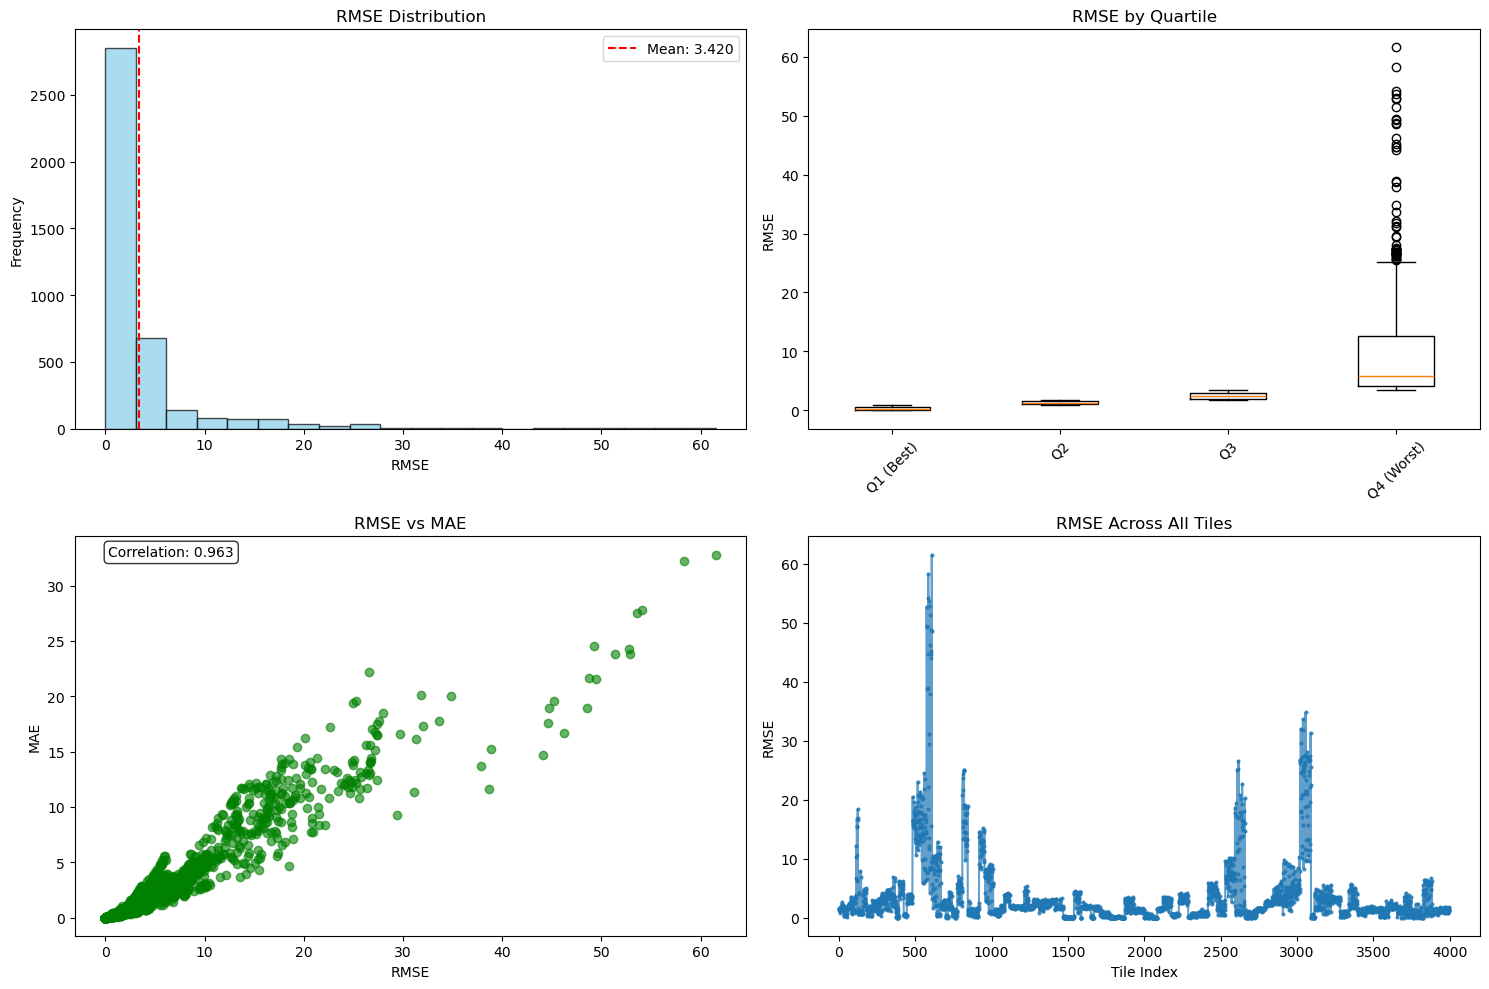


Visualization created for 4000 tiles


In [40]:
# Create basic visualizations
plt.style.use('default')
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 10})

# 1. Distribution of primary metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0,0].hist(metrics_df[metric], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title(f'{metric.upper()} Distribution')
axes[0,0].set_xlabel(metric.upper())
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(metrics_df[metric].mean(), color='red', linestyle='--', label=f'Mean: {metrics_df[metric].mean():.3f}')
axes[0,0].legend()

# Box plot by quartiles
quartile_labels = []
quartile_values = []
for q_name, q_data in quartiles.items():
    quartile_labels.append(q_name)
    quartile_values.append(q_data[metric].values)

axes[0,1].boxplot(quartile_values, labels=quartile_labels)
axes[0,1].set_title(f'{metric.upper()} by Quartile')
axes[0,1].set_ylabel(metric.upper())
axes[0,1].tick_params(axis='x', rotation=45)

# Scatter plot of different metrics (if available)
if 'mae' in metrics_df.columns:
    axes[1,0].scatter(metrics_df[metric], metrics_df['mae'], alpha=0.6, color='green')
    axes[1,0].set_xlabel(metric.upper())
    axes[1,0].set_ylabel('MAE')
    axes[1,0].set_title(f'{metric.upper()} vs MAE')
    
    # Add correlation coefficient
    corr = metrics_df[metric].corr(metrics_df['mae'])
    axes[1,0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1,0].transAxes, 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Performance over tile index (if ordered)
axes[1,1].plot(range(len(metrics_df)), metrics_df[metric].values, marker='o', markersize=2, alpha=0.7)
axes[1,1].set_title(f'{metric.upper()} Across All Tiles')
axes[1,1].set_xlabel('Tile Index')
axes[1,1].set_ylabel(metric.upper())

plt.tight_layout()
plt.show()

print(f"\nVisualization created for {len(metrics_df)} tiles")

In [41]:
# Enhanced tile visualization with real data priority
def load_and_visualize_tile(tile_name, dataset_path, output_path, tile_metrics):
    """Load and visualize a single tile with all components."""
    print(f"  Attempting to load real data for: {tile_name}")
    
    try:
        import cv2
        
        # Find DSM prediction directories with wildcards
        import glob
        dsm_plus_dirs = []  # dsm_*+ (denoised by DAE - highest priority)
        dsm_base_dirs = []  # dsm_* (base MTL output - lower priority)
        
        if os.path.exists(output_path):
            # Look for dsm_*+ directories (e.g., dsm_110+, dsm_111+, dsm_010+)
            plus_pattern = os.path.join(output_path, 'dsm_*+')
            dsm_plus_dirs = [os.path.basename(p) for p in glob.glob(plus_pattern) if os.path.isdir(p)]
            
            # Look for dsm_* directories (e.g., dsm_110, dsm_111, dsm_010)
            base_pattern = os.path.join(output_path, 'dsm_*')
            all_dsm_dirs = [os.path.basename(p) for p in glob.glob(base_pattern) if os.path.isdir(p)]
            # Filter out the + versions to get only base versions
            dsm_base_dirs = [d for d in all_dsm_dirs if not d.endswith('+')]
            
            dsm_plus_dirs.sort()  # Sort for consistent ordering
            dsm_base_dirs.sort()
        
        # Prediction directories in priority order:
        # 1. dsm_*+ (denoised by DAE - highest priority)
        # 2. dsm_* (base MTL output - lower priority)
        pred_dirs_to_try = dsm_plus_dirs + dsm_base_dirs
        
        # Construct file paths with multiple extension support
        file_extensions = ['.tif', '.tiff', '.png', '.jpg', '.jpeg']
        
        # Find RGB file
        rgb_path = None
        for ext in file_extensions:
            potential_rgb = os.path.join(dataset_path, 'test', 'rgb', f'{tile_name}{ext}')
            if os.path.exists(potential_rgb):
                rgb_path = potential_rgb
                break
        
        # Find ground truth DSM file
        gt_dsm_path = None
        for ext in file_extensions:
            potential_gt = os.path.join(dataset_path, 'test', 'dsm', f'{tile_name}{ext}')
            if os.path.exists(potential_gt):
                gt_dsm_path = potential_gt
                break
        
        # Try to find prediction file in various directories
        pred_dsm_path = None
        for pred_dir in pred_dirs_to_try:
            for ext in file_extensions:
                potential_path = os.path.join(output_path, pred_dir, f'{tile_name}{ext}')
                if os.path.exists(potential_path):
                    pred_dsm_path = potential_path
                    print(f"    Found predictions in: {pred_dir}/ with extension {ext}")
                    break
            if pred_dsm_path:  # Break outer loop if found
                break
        
        # Debug path information
        print(f"    RGB path: {rgb_path} - Exists: {rgb_path and os.path.exists(rgb_path)}")
        print(f"    GT DSM path: {gt_dsm_path} - Exists: {gt_dsm_path and os.path.exists(gt_dsm_path)}")
        print(f"    Pred DSM path: {pred_dsm_path} - Exists: {pred_dsm_path and os.path.exists(pred_dsm_path)}")
        
        # Check if all required files exist
        if not rgb_path:
            return f"RGB file not found with any extension {file_extensions} in: {os.path.join(dataset_path, 'test', 'rgb')}"
        if not gt_dsm_path:
            return f"Ground truth DSM not found with any extension {file_extensions} in: {os.path.join(dataset_path, 'test', 'dsm')}"
        if not pred_dsm_path:
            return f"Prediction DSM not found with any extension {file_extensions} in directories: {pred_dirs_to_try}"
        
        # Load images
        print(f"    Loading RGB...")
        rgb = cv2.imread(rgb_path)
        if rgb is not None:
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        
        print(f"    Loading ground truth DSM...")
        gt_dsm = cv2.imread(gt_dsm_path, cv2.IMREAD_UNCHANGED)
        if gt_dsm is None:
            return f"Failed to load ground truth DSM: {gt_dsm_path}"
        gt_dsm = gt_dsm.astype(np.float32)
        
        print(f"    Loading predicted DSM...")
        pred_dsm = cv2.imread(pred_dsm_path, cv2.IMREAD_UNCHANGED)
        if pred_dsm is None:
            return f"Failed to load predicted DSM: {pred_dsm_path}"
        pred_dsm = pred_dsm.astype(np.float32)
        
        # Handle multi-channel DSMs (take first channel if needed)
        if len(gt_dsm.shape) == 3:
            gt_dsm = gt_dsm[:,:,0]
        if len(pred_dsm.shape) == 3:
            pred_dsm = pred_dsm[:,:,0]
        
        # Calculate difference
        diff_dsm = np.abs(pred_dsm - gt_dsm)
        
        print(f"    Creating visualization...")
        print(f"    Data shapes: RGB={rgb.shape if rgb is not None else 'None'}, GT={gt_dsm.shape}, Pred={pred_dsm.shape}")
        print(f"    Height ranges: GT=[{gt_dsm.min():.1f}, {gt_dsm.max():.1f}], Pred=[{pred_dsm.min():.1f}, {pred_dsm.max():.1f}]")
        
        # Create visualization
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # RGB image
        if rgb is not None:
            axes[0].imshow(rgb)
            axes[0].set_title('RGB Image')
        else:
            axes[0].text(0.5, 0.5, 'RGB not available', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].axis('off')
        
        # Ground truth DSM
        im1 = axes[1].imshow(gt_dsm, cmap='terrain')
        axes[1].set_title('Ground Truth DSM')
        plt.colorbar(im1, ax=axes[1], shrink=0.8, label='Height (m)')
        axes[1].axis('off')
        
        # Predicted DSM
        im2 = axes[2].imshow(pred_dsm, cmap='terrain')
        axes[2].set_title('Predicted DSM')
        plt.colorbar(im2, ax=axes[2], shrink=0.8, label='Height (m)')
        axes[2].axis('off')
        
        # Difference map
        im3 = axes[3].imshow(diff_dsm, cmap='hot')
        axes[3].set_title('Absolute Difference')
        plt.colorbar(im3, ax=axes[3], shrink=0.8, label='Error (m)')
        axes[3].axis('off')
        
        # Get metrics for title
        rmse_val = tile_metrics[metric] if metric in tile_metrics else 0
        mae_val = tile_metrics.get('mae', 0)
        delta1_val = tile_metrics.get('delta1', 0)
        
        # Set overall title
        title = f'Tile: {tile_name} (REAL DATA)\nRMSE: {rmse_val:.3f} | MAE: {mae_val:.3f}'
        if delta1_val > 0:
            title += f' | Delta1: {delta1_val:.3f}'
        
        plt.suptitle(title, fontsize=14, y=1.05)
        plt.tight_layout()
        plt.show()
        
        return "Success"
        
    except ImportError:
        return "OpenCV not available - install with: pip install opencv-python"
    except Exception as e:
        return f"Error loading real data: {e}"

# Setup information for tile visualization
print("=== TILE VISUALIZATION SETUP ===")
print("This notebook uses the load_and_visualize_tile() function for displaying tiles.")
print("Tile visualizations are shown in the quartile analysis section below.\n")

# Check if we're using real data or mock data
using_real_metrics = os.path.exists(LOG_FILE)
print(f"Data source verification:")
print(f"  Using real metrics data: {using_real_metrics}")
print(f"  Dataset path exists: {os.path.exists(DATASET_PATH)}")
print(f"  Output path exists: {os.path.exists(OUTPUT_PATH)}")

# Check if output path has prediction directories
if os.path.exists(OUTPUT_PATH):
    pred_dirs = [d for d in os.listdir(OUTPUT_PATH) if os.path.isdir(os.path.join(OUTPUT_PATH, d)) and 'dsm' in d.lower()]
    print(f"  Available prediction directories: {pred_dirs}")
else:
    print(f"  Output path does not exist: {OUTPUT_PATH}")

print(f"\nNote: Individual tile visualizations are shown in the quartile section below.")

print(f"\n📋 TROUBLESHOOTING GUIDE:")
print(f"If you see mock data instead of real data:")
print(f"  1. Verify dataset path: {DATASET_PATH}")
print(f"  2. Check for test/rgb and test/dsm directories")
print(f"  3. Verify output path: {OUTPUT_PATH}")
print(f"  4. Check for prediction directories (dsm_110+, dsm_110, etc.)")
print(f"  5. Ensure tile names in log match actual file names")
print(f"  6. Install OpenCV: pip install opencv-python")

=== TILE VISUALIZATION SETUP ===
This notebook uses the load_and_visualize_tile() function for displaying tiles.
Tile visualizations are shown in the quartile analysis section below.

Data source verification:
  Using real metrics data: True
  Dataset path exists: True
  Output path exists: True
  Available prediction directories: ['dsm_110+', 'dsm_110']

Note: Individual tile visualizations are shown in the quartile section below.

📋 TROUBLESHOOTING GUIDE:
If you see mock data instead of real data:
  1. Verify dataset path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin
  2. Check for test/rgb and test/dsm directories
  3. Verify output path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin
  4. Check for prediction directories (dsm_110+, dsm_110, etc.)
  5. Ensure tile names in log match actual file names
  6. Install OpenCV: pip install opencv-python



=== QUARTILE SAMPLE VISUALIZATIONS ===
Showing one representative sample from each quartile for comparison...


Q1 (BEST) - REPRESENTATIVE SAMPLE:
Tile: OMA_258_030_crop05
  RMSE: 0.354
  MAE: 0.090
  Delta1: 0.935
  Attempting to load real data for: OMA_258_030_crop05
    Found predictions in: dsm_110+/ with extension .tif
    RGB path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/rgb/OMA_258_030_crop05.tif - Exists: True
    GT DSM path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/dsm/OMA_258_030_crop05.tif - Exists: True
    Pred DSM path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/dsm_110+/OMA_258_030_crop05.tif - Exists: True
    Loading RGB...
    Loading ground truth DSM...
    Loading predicted DSM...
    Creating visualization...
    Data shapes: RGB=(512, 512, 3), GT=(512, 512), Pred=(512, 512)
    Height ranges: GT=[0.0, 0.0], Pred=[0.0, 1.4]


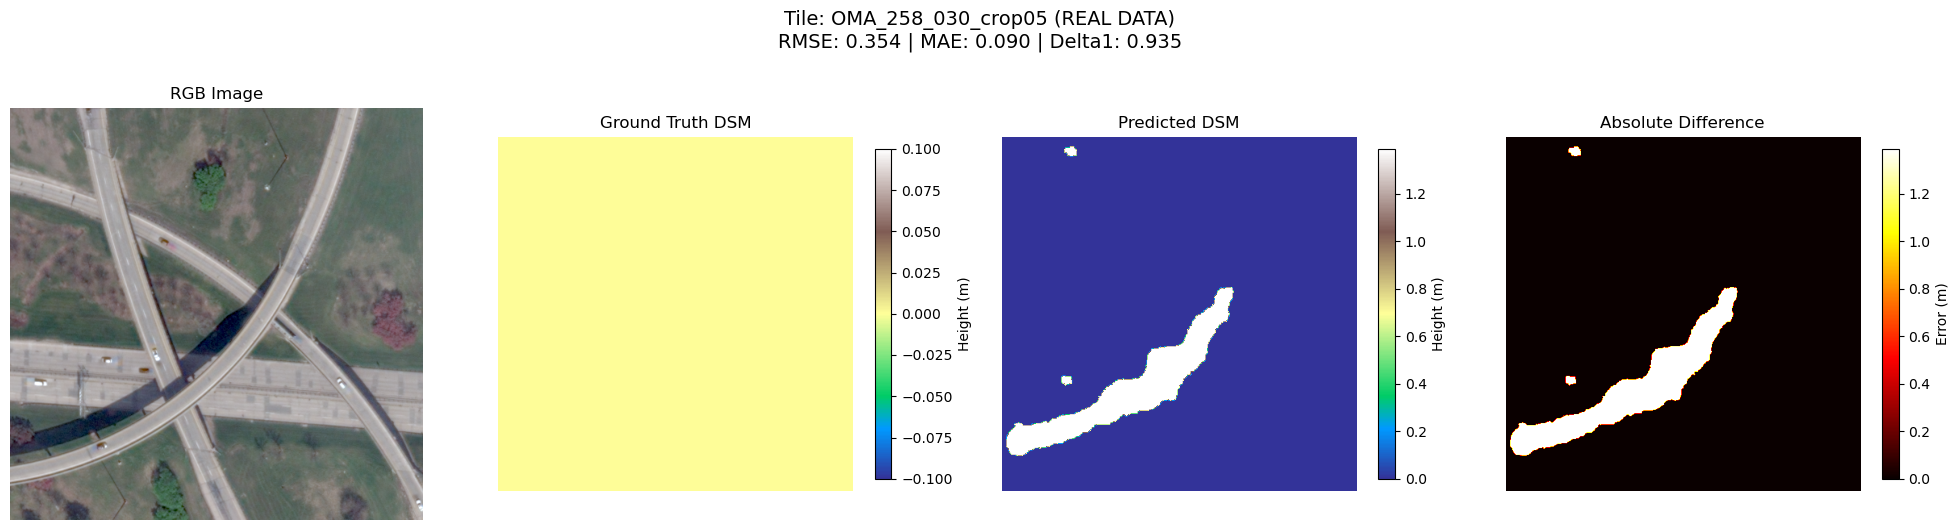

  ✅ Successfully visualized real data!
------------------------------------------------------------

Q2 - REPRESENTATIVE SAMPLE:
Tile: OMA_389_015_crop04
  RMSE: 1.362
  MAE: 0.443
  Delta1: 0.873
  Attempting to load real data for: OMA_389_015_crop04
    Found predictions in: dsm_110+/ with extension .tif
    RGB path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/rgb/OMA_389_015_crop04.tif - Exists: True
    GT DSM path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/dsm/OMA_389_015_crop04.tif - Exists: True
    Pred DSM path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/dsm_110+/OMA_389_015_crop04.tif - Exists: True
    Loading RGB...
    Loading ground truth DSM...
    Loading predicted DSM...
    Creating visualization...
    Data shapes: RGB=(512, 512, 3), GT=(512, 512), Pred=(512, 512)
    Height ranges: GT=[-0.1, 7.0], Pred=[0.0, 1.4]


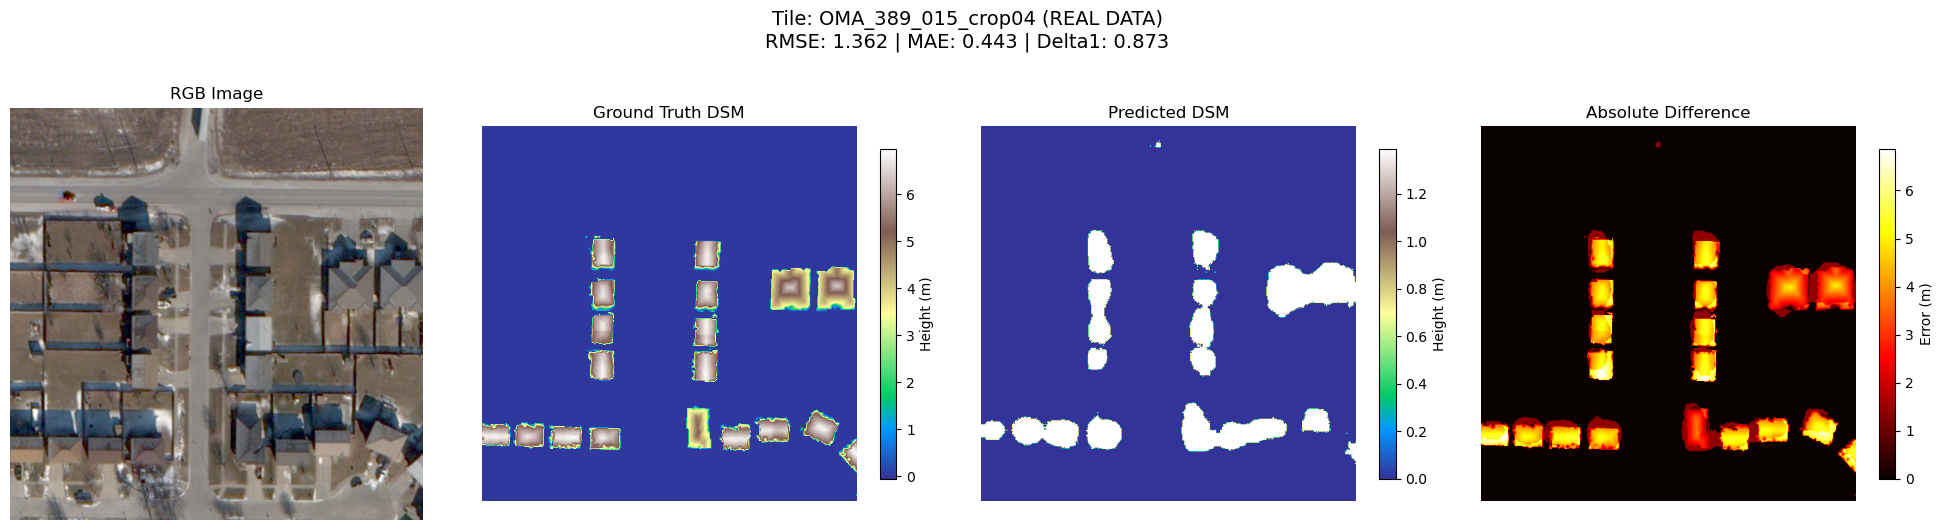

  ✅ Successfully visualized real data!
------------------------------------------------------------

Q3 - REPRESENTATIVE SAMPLE:
Tile: JAX_280_025_crop07
  RMSE: 2.510
  MAE: 0.848
  Delta1: 0.856
  Attempting to load real data for: JAX_280_025_crop07
    Found predictions in: dsm_110+/ with extension .tif
    RGB path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/rgb/JAX_280_025_crop07.tif - Exists: True
    GT DSM path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/dsm/JAX_280_025_crop07.tif - Exists: True
    Pred DSM path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/dsm_110+/JAX_280_025_crop07.tif - Exists: True
    Loading RGB...
    Loading ground truth DSM...
    Loading predicted DSM...
    Creating visualization...
    Data shapes: RGB=(512, 512, 3), GT=(512, 512), Pred=(512, 512)
    Height ranges: GT=[-0.0, 18.9], Pred=[0.0, 1.4]


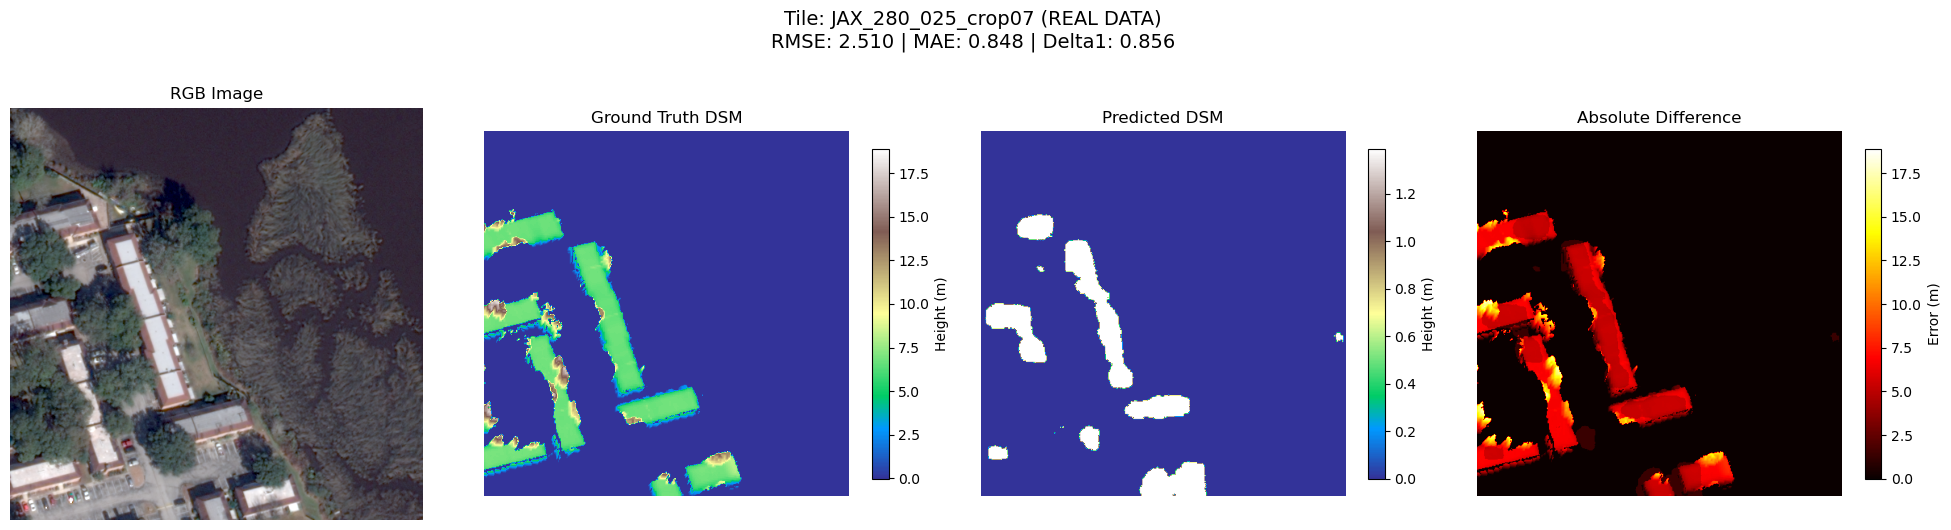

  ✅ Successfully visualized real data!
------------------------------------------------------------

Q4 (WORST) - REPRESENTATIVE SAMPLE:
Tile: JAX_260_026_crop05
  RMSE: 6.134
  MAE: 1.390
  Delta1: 0.901
  Attempting to load real data for: JAX_260_026_crop05
    Found predictions in: dsm_110+/ with extension .tif
    RGB path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/rgb/JAX_260_026_crop05.tif - Exists: True
    GT DSM path: /home/asfand/Ahmad/datasets/DFC2019_crp512_bin/test/dsm/JAX_260_026_crop05.tif - Exists: True
    Pred DSM path: /home/asfand/Ahmad/DSMNet/output/DFC2019_crp512_bin/dsm_110+/JAX_260_026_crop05.tif - Exists: True
    Loading RGB...
    Loading ground truth DSM...
    Loading predicted DSM...
    Creating visualization...
    Data shapes: RGB=(512, 512, 3), GT=(512, 512), Pred=(512, 512)
    Height ranges: GT=[-0.0, 39.1], Pred=[0.0, 1.4]


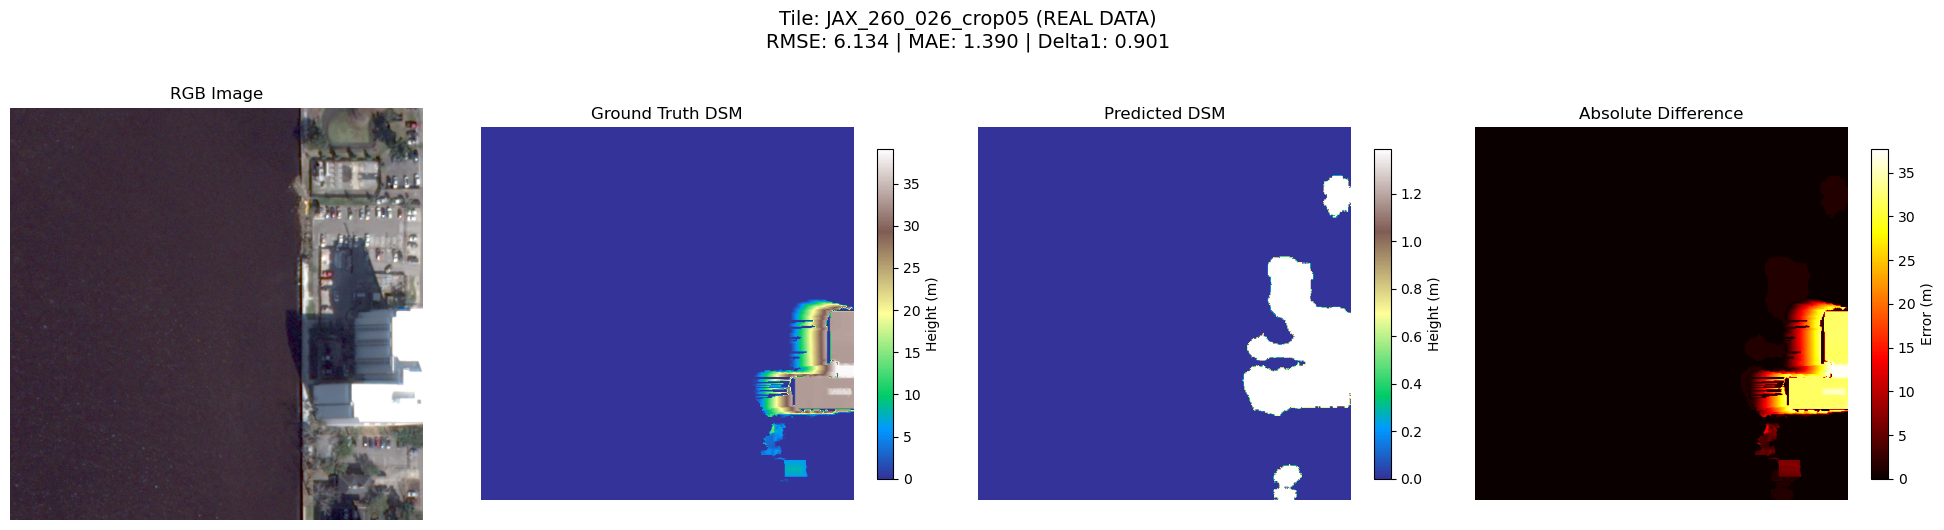

  ✅ Successfully visualized real data!
------------------------------------------------------------


In [42]:
# Optional: Show more tile samples from each quartile
show_more_samples = True  # Set to True to see more tiles

if show_more_samples:
    print("\n=== QUARTILE SAMPLE VISUALIZATIONS ===")
    print("Showing one representative sample from each quartile for comparison...\n")
    
    for q_name, q_samples in sampled_tiles.items():
        print(f"\n{q_name.upper()} - REPRESENTATIVE SAMPLE:")
        print("=" * 60)
        
        # Show first sample from each quartile
        sample_row = q_samples.iloc[0]
        tile_name = sample_row['tile_name']
        
        print(f"Tile: {tile_name}")
        print(f"  RMSE: {sample_row[metric]:.3f}")
        if 'mae' in sample_row:
            print(f"  MAE: {sample_row['mae']:.3f}")
        if 'delta1' in sample_row:
            print(f"  Delta1: {sample_row['delta1']:.3f}")
        
        # Attempt visualization
        result = load_and_visualize_tile(tile_name, DATASET_PATH, OUTPUT_PATH, sample_row)
        if result != "Success":
            print(f"  ❌ Could not load real data: {result}")
            print(f"  ⚠️  Showing mock visualization for demonstration...")
            
            # Create mock visualization as fallback
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            
            # Mock data based on actual tile metrics
            np.random.seed(hash(tile_name) % 2**32)
            mock_rgb = np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8)
            mock_gt = np.random.rand(256, 256) * 50
            mock_pred = mock_gt + np.random.normal(0, sample_row[metric], (256, 256))
            mock_diff = np.abs(mock_pred - mock_gt)
            
            axes[0].imshow(mock_rgb)
            axes[0].set_title('RGB Image (Mock)')
            axes[0].axis('off')
            
            im1 = axes[1].imshow(mock_gt, cmap='terrain')
            axes[1].set_title('Ground Truth DSM (Mock)')
            plt.colorbar(im1, ax=axes[1], shrink=0.8)
            axes[1].axis('off')
            
            im2 = axes[2].imshow(mock_pred, cmap='terrain')
            axes[2].set_title('Predicted DSM (Mock)')
            plt.colorbar(im2, ax=axes[2], shrink=0.8)
            axes[2].axis('off')
            
            im3 = axes[3].imshow(mock_diff, cmap='hot')
            axes[3].set_title('Absolute Difference (Mock)')
            plt.colorbar(im3, ax=axes[3], shrink=0.8)
            axes[3].axis('off')
            
            plt.suptitle(f'{q_name} Sample: {tile_name} (MOCK DATA)\nRMSE: {sample_row[metric]:.3f}', fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  ✅ Successfully visualized real data!")
        
        print("-" * 60)

else:
    print("\n=== ADDITIONAL SAMPLES ===")
    print("To see sample tiles from each quartile:")
    print("  Set 'show_more_samples = True' in the cell above and re-run")
    
    # Show summary of available samples
    print(f"\nAvailable samples per quartile:")
    for q_name, q_samples in sampled_tiles.items():
        print(f"  {q_name}: {len(q_samples)} samples available")
        sample_rmse_values = [row[metric] for _, row in q_samples.iterrows()]
        print(f"    RMSE range: [{min(sample_rmse_values):.3f}, {max(sample_rmse_values):.3f}]")

In [43]:
# Final Summary Report
print("=" * 70)
print(f"SIMPLE DSM ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nDataset: {DATASET_NAME}")
print(f"Total tiles analyzed: {len(metrics_df)}")
print(f"Primary metric: {metric.upper()}")

if metric in metrics_df.columns:
    print(f"\n{metric.upper()} Performance Overview:")
    print(f"  Best tile: {quartiles['Q1 (Best)'].iloc[0]['tile_name']} ({quartiles['Q1 (Best)'][metric].min():.3f})")
    print(f"  Worst tile: {quartiles['Q4 (Worst)'].iloc[-1]['tile_name']} ({quartiles['Q4 (Worst)'][metric].max():.3f})")
    print(f"  Overall mean: {metrics_df[metric].mean():.3f}")
    print(f"  Overall std: {metrics_df[metric].std():.3f}")
    print(f"  Performance improvement potential: {((quartiles['Q4 (Worst)'][metric].mean() - quartiles['Q1 (Best)'][metric].mean()) / quartiles['Q4 (Worst)'][metric].mean() * 100):.1f}%")

print(f"\nQuartile Breakdown:")
for q_name, q_data in quartiles.items():
    q_mean = q_data[metric].mean()
    q_count = len(q_data)
    q_range = f"[{q_data[metric].min():.3f}-{q_data[metric].max():.3f}]"
    print(f"  {q_name}: {q_count} tiles, mean {metric}={q_mean:.3f}, range={q_range}")

print(f"\nVisualizations Created:")
print(f"  ✓ Distribution histogram with quartile analysis")
print(f"  ✓ Quartile box plots showing performance spread")
print(f"  ✓ Metric correlation analysis")
print(f"  ✓ Performance trend across all tiles")
print(f"  ✓ Complete tile visualizations (RGB + GT DSM + Pred DSM + Diff)")
print(f"  ✓ Best vs worst tile comparison")

# Available metrics summary
available_metrics = [col for col in metrics_df.columns if col != 'tile_name']
print(f"\nAvailable metrics: {available_metrics}")

# Data source information
data_source = "Real log data" if os.path.exists(LOG_FILE) else "Mock data (for demonstration)"
print(f"\nData source: {data_source}")
if not os.path.exists(LOG_FILE):
    print(f"  Note: No log file found at {LOG_FILE}")
    print(f"  Using generated mock data to demonstrate functionality")

print(f"\n" + "=" * 70)
print(f"ANALYSIS COMPLETE!")
print(f"=" * 70)

print(f"\nTo analyze a different dataset:")
print(f"  1. Change DATASET_NAME in the configuration cell")
print(f"  2. Re-run all cells")

print(f"\nKey Insights:")
print(f"  • Focus on Q4 (worst) tiles for model improvement")
print(f"  • Analyze patterns in difference maps to identify failure modes")
print(f"  • Compare RGB features between best/worst performing tiles")
print(f"  • Use quartile thresholds for validation set filtering")

print(f"\nNext steps:")
print(f"  • Investigate spatial patterns in poor performance")
print(f"  • Analyze correlation with building density/height")
print(f"  • Compare different model outputs (MTL vs MTL+DAE)")
print(f"  • Create performance maps for geographic analysis")

SIMPLE DSM ANALYSIS SUMMARY

Dataset: DFC2019_crp512_bin
Total tiles analyzed: 4000
Primary metric: RMSE

RMSE Performance Overview:
  Best tile: OMA_292_010_crop01 (0.000)
  Worst tile: JAX_167_026_crop01 (61.535)
  Overall mean: 3.420
  Overall std: 5.533
  Performance improvement potential: 96.4%

Quartile Breakdown:
  Q1 (Best): 1000 tiles, mean rmse=0.340, range=[0.000-0.852]
  Q2: 1000 tiles, mean rmse=1.328, range=[0.852-1.731]
  Q3: 1000 tiles, mean rmse=2.474, range=[1.736-3.391]
  Q4 (Worst): 1000 tiles, mean rmse=9.538, range=[3.393-61.535]

Visualizations Created:
  ✓ Distribution histogram with quartile analysis
  ✓ Quartile box plots showing performance spread
  ✓ Metric correlation analysis
  ✓ Performance trend across all tiles
  ✓ Complete tile visualizations (RGB + GT DSM + Pred DSM + Diff)
  ✓ Best vs worst tile comparison

Available metrics: ['mae', 'rmse', 'delta1', 'delta2', 'delta3', 'rmse_building', 'rmse_matched', 'low_rise_rmse', 'mid_rise_rmse', 'processing_t